In [1]:
import os
os.environ['JAX_ENABLE_X64'] = '1'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.3' 

from temgym_core.components import Detector
from temgym_core.utils import wavelength2energy
from temgym_core.gaussian_action2D import (make_gaussian, run_to_end, Lens)
import jax.numpy as jnp
import numpy as np
from temgym_core.evaluate import evaluate_gaussians_for
from temgym_core.utils import zero_phase, make_aperture, FresnelPropagator
import matplotlib.pyplot as plt
import jax
from temgym_core.utils import energy2wavelength, fresnel_lens_imaging_solution
from skimage.restoration import unwrap_phase
from temgym_core.gaussian_action2D import ABCDPropagator2D
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

%matplotlib widget

In [2]:
def _detector_mesh(detector: Detector) -> tuple[np.ndarray, np.ndarray]:
    det_edge_x, det_edge_y = detector.coords_1d
    det_edge_x = np.asarray(det_edge_x)
    det_edge_y = np.asarray(det_edge_y)
    Y, X = np.meshgrid(det_edge_y, det_edge_x, indexing="ij")
    return Y, X

def _window_size(detector: Detector) -> float:
    width_x = float(detector.pixel_size[1]) * detector.shape[1]
    return width_x

def calculate_z1_and_z2_from_M_and_f(M, f):
    """
    Given the magnification M and focal length f,
    calculate the distances z1 and z2 for a two-lens system
    to satisfy the imaging condition.
    """
    z1 = f * (1/M - 1)
    z2 = f * (1 - M)
    return z1, z2

def _field_on_grid(ray, grid: Detector) -> np.ndarray:
    field = evaluate_gaussians_for(ray, grid)
    return np.asarray(field)

In [3]:
propagation_distance = 1000
pixel_size = (0.000005, 0.000005)
voltage = 1e-2
wavelength = energy2wavelength(voltage)
k = 2 * jnp.pi / wavelength
wo = 0.001
shape = (4096, 4096)

input_grid = Detector(z=0.0, pixel_size=pixel_size, shape=shape)
detector = Detector(z=propagation_distance, pixel_size=pixel_size, shape=shape)

gaussian = make_gaussian(
    x=0.0,
    y=0.0,
    dx=0.0,
    dy=0.0,
    z=0.0,
    voltage=voltage,
    waist_x=wo,
    waist_y=wo,
    amp=1.0,
    phase=0.0,
    rcurv_x=jnp.inf,
    rcurv_y=jnp.inf,
)

propagated = run_to_end(gaussian, (detector,))
analytic_gauss_image = evaluate_gaussians_for(propagated, detector)

gauss_input = evaluate_gaussians_for(gaussian, input_grid)
gauss_input = zero_phase(gauss_input, shape[0]//2, shape[1]//2)


Y, X = _detector_mesh(detector)

fresnel_gauss_image = FresnelPropagator(
    gauss_input,
    _window_size(detector),
    wavelength,
    propagation_distance,
)
analytic_gauss_image = np.array(analytic_gauss_image)
fresnel_gauss_image = np.array(fresnel_gauss_image)

det_circular_mask = make_aperture(X, Y, aperture_ratio=0.7)

analytic_gauss_image *= det_circular_mask
fresnel_gauss_image *= det_circular_mask

analytic_gauss_image = np.where(
    det_circular_mask,
    analytic_gauss_image,
    np.abs(analytic_gauss_image),
)
fresnel_gauss_image = np.where(
    det_circular_mask,
    fresnel_gauss_image,
    np.abs(fresnel_gauss_image),
)

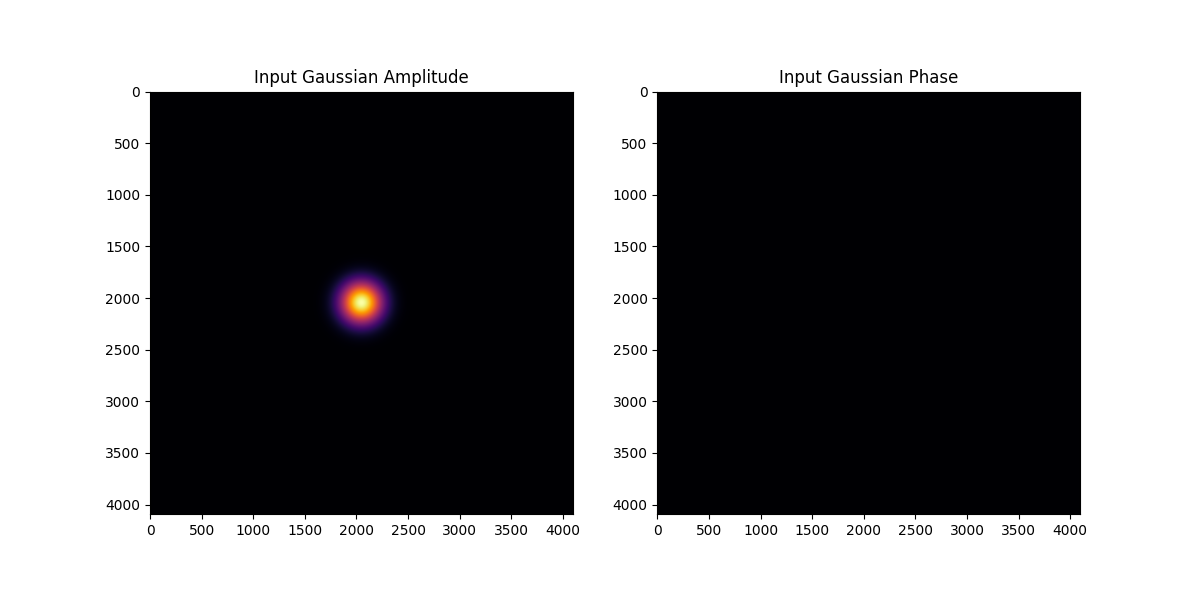

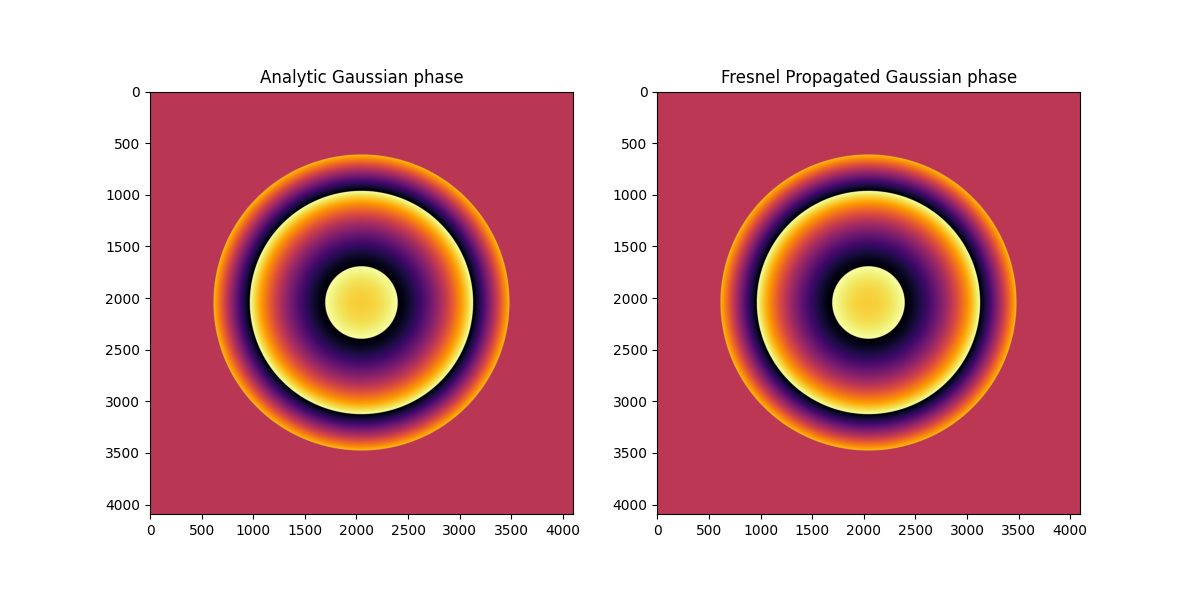

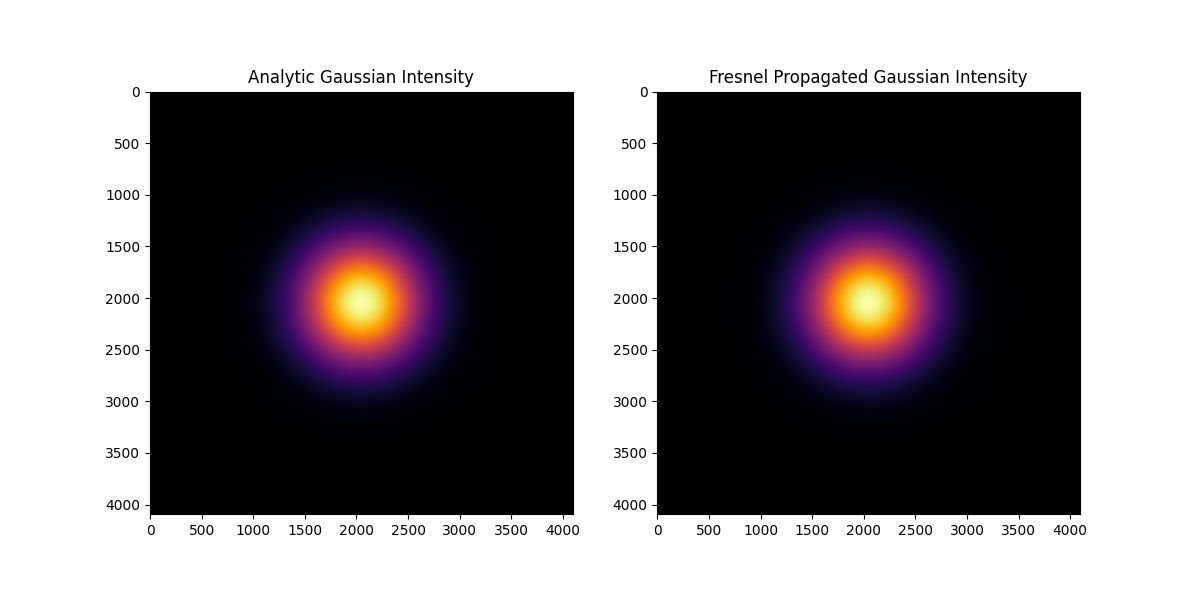

In [4]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Input Gaussian Amplitude")
plt.imshow(np.abs(gauss_input), cmap="inferno")
plt.subplot(1, 2, 2)
plt.title("Input Gaussian Phase")
plt.imshow(np.angle(gauss_input), cmap="inferno")
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Analytic Gaussian phase")
plt.imshow(np.angle(analytic_gauss_image), cmap="inferno")
plt.subplot(1, 2, 2)
plt.title("Fresnel Propagated Gaussian phase")
plt.imshow(np.angle(fresnel_gauss_image), cmap="inferno")
plt.show()

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Analytic Gaussian Intensity")
plt.imshow(np.abs(analytic_gauss_image) ** 2, cmap="inferno")
plt.subplot(1, 2, 2)
plt.title("Fresnel Propagated Gaussian Intensity")
plt.imshow(np.abs(fresnel_gauss_image) ** 2, cmap="inferno")
plt.show()


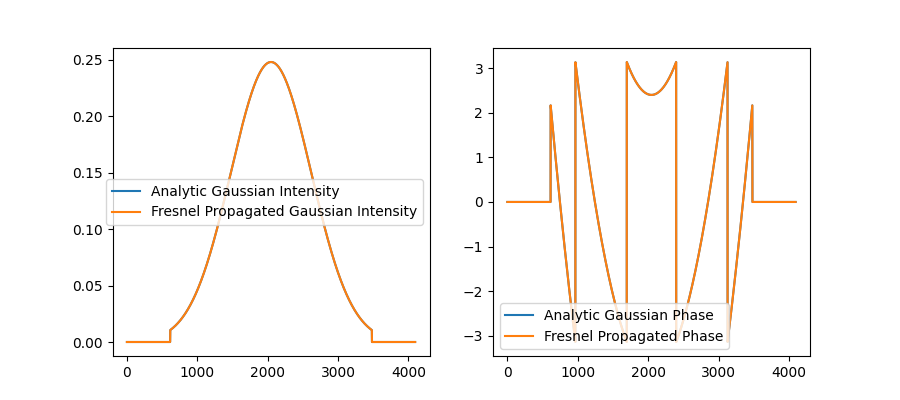

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
axs[0].plot(
    np.abs(analytic_gauss_image[shape[0] // 2, :]),
    label="Analytic Gaussian Intensity",
)
axs[0].plot(
    np.abs(fresnel_gauss_image[shape[0] // 2, :]) ,
    label="Fresnel Propagated Gaussian Intensity",
)
axs[1].plot(
    np.angle(analytic_gauss_image[shape[0] // 2, :]),
    label="Analytic Gaussian Phase",
)
axs[1].plot(
    np.angle(fresnel_gauss_image[shape[0] // 2, :]),
    label="Fresnel Propagated Phase",
)
axs[0].legend()
axs[1].legend()
plt.show()

In [9]:
M = -2
f = 5e-3
defocus = 0.0
z1, z2 = calculate_z1_and_z2_from_M_and_f(M, f)

pixel_size = (1e-6, 1e-6)
shape = (4096, 4096)
voltage = 1e-9
wavelength = energy2wavelength(voltage)
wo = 5e-4

input_grid = Detector(z=0.0, pixel_size=pixel_size, shape=shape)
lens = Lens(z=abs(z1), focal_length=f)
detector = Detector(z=abs(z1) + z2 + defocus, pixel_size=pixel_size, shape=shape)

gaussian = make_gaussian(
    x=0.0,
    y=0.0,
    dx=0.0,
    dy=0.0,
    z=0.0,
    voltage=voltage,
    waist_x=wo,
    waist_y=wo,
    amp=1.0,
    phase=0.0,
    rcurv_x=jnp.inf,
    rcurv_y=jnp.inf,
)

propagated = run_to_end(gaussian, (lens, detector))
analytic_gauss_image = _field_on_grid(propagated, detector)

gauss_input = _field_on_grid(gaussian, input_grid)
gauss_input = zero_phase(
    gauss_input,
    gauss_input.shape[0] // 2,
    gauss_input.shape[1] // 2,
)

Y, X = _detector_mesh(detector)
fresnel_gauss_image = fresnel_lens_imaging_solution(
    gauss_input,
    Y,
    X,
    pixel_size[0],
    wavelength,
    z1,
    f,
    z2 + defocus,
)

analytic_gauss_image = np.array(analytic_gauss_image)
fresnel_gauss_image = np.array(fresnel_gauss_image)

det_circular_mask = make_aperture(X, Y, aperture_ratio=0.3)

analytic_gauss_image *= det_circular_mask
fresnel_gauss_image *= det_circular_mask

analytic_gauss_image = np.where(
    det_circular_mask,
    analytic_gauss_image,
    np.abs(analytic_gauss_image),
)
fresnel_gauss_image = np.where(
    det_circular_mask,
    fresnel_gauss_image,
    np.abs(fresnel_gauss_image),
)


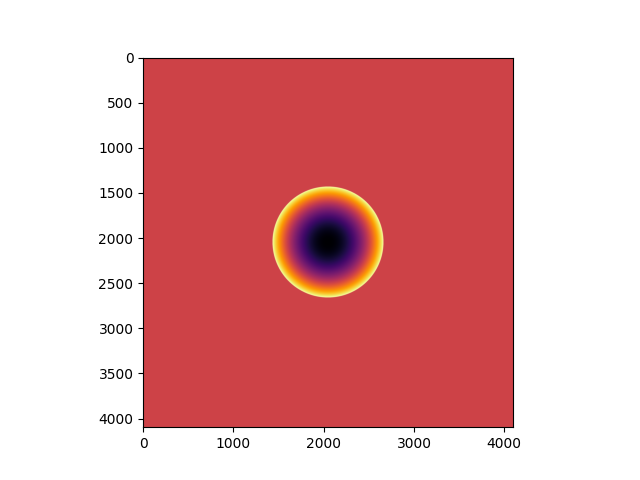

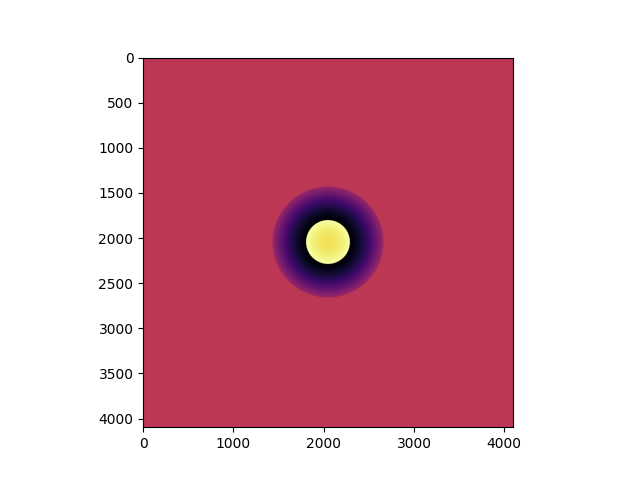

In [10]:

plt.figure()
plt.imshow(np.angle(analytic_gauss_image), cmap="inferno")

plt.figure()
plt.imshow(np.angle(fresnel_gauss_image), cmap="inferno")
plt.show()



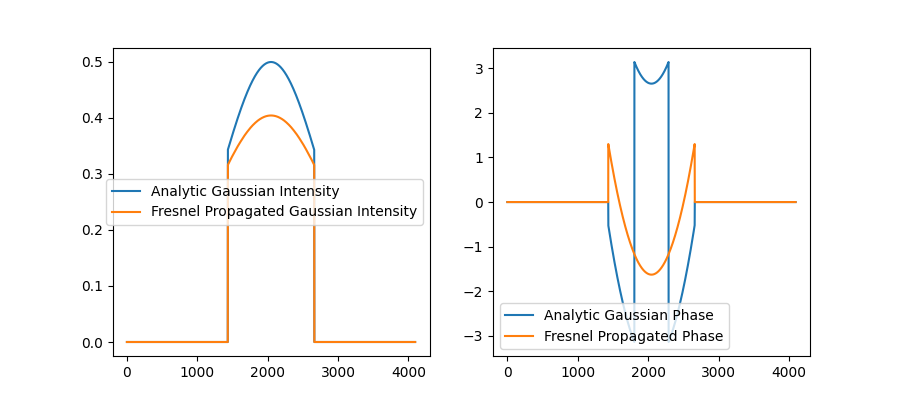

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(9, 4))
axs[0].plot(
    np.abs(analytic_gauss_image[shape[0] // 2, :]),
    label="Analytic Gaussian Intensity",
)
axs[0].plot(
    np.abs(fresnel_gauss_image[shape[0] // 2, :]) ,
    label="Fresnel Propagated Gaussian Intensity",
)
axs[1].plot(
    np.angle(analytic_gauss_image[shape[0] // 2, :]),
    label="Analytic Gaussian Phase",
)
axs[1].plot(
    np.angle(fresnel_gauss_image[shape[0] // 2, :]),
    label="Fresnel Propagated Phase",
)
axs[0].legend()
axs[1].legend()
plt.show()

In [ ]:
def test_fourier_transform_ABCD_matrix_updates_against_stepwise():
    # Test general ABCD transform: A=0, B=f, C=-1/f, D=0
    voltage = 300000
    r_curv = jnp.inf
    waist = 3e-8

    ray_in = make_gaussian(
        x=0.0e-6,
        y=0.2e-6,
        dx=0.0,
        dy=0.0,
        z=0.0,
        voltage=voltage,
        waist_x=waist,
        waist_y=waist,
        phase=0.0,
        amp=1.0,
        rcurv_x=r_curv,
        rcurv_y=r_curv,
    )
    f = 1e-2
    ray_out_abcd = ABCDPropagator2D.fourier_transform(f)(ray_in)

    lens = Lens(z=f, focal_length=f)
    output_probe_grid = Detector(z=2 * f, pixel_size=(1, 1), shape=(1, 1))

    components = (lens, output_probe_grid)
    ray_out_step_wise = run_to_end(ray_in, components)

    print(ray_out_abcd.C)
    print(ray_out_step_wise.C)

    np.testing.assert_allclose(
        ray_out_abcd.S2,
        ray_out_step_wise.S2,
        rtol=1e-5,
    )
    np.testing.assert_allclose(
        ray_out_abcd.C,
        ray_out_step_wise.C,
        rtol=1e-5,
    )

test_fourier_transform_ABCD_matrix_updates_against_stepwise()

Question, why is there a linear imaginary action term after propagation?

In [ ]:
from temgym_core.gaussian_action2D import center_shift_from_S

voltage = 100e3
ray_in = make_gaussian(
        x=0.0e-6,
        y=0.2e-6,
        dx=1e-4,
        dy=0.0,
        z=0.0,
        voltage=voltage,
        waist_x=1e-3,
        waist_y=1e-3,
        phase=0.0,
        amp=1.0,
        rcurv_x=jnp.inf,
        rcurv_y=jnp.inf,
    )

wavelength = energy2wavelength(voltage)
k = 2 * jnp.pi / wavelength

z = 1e-2

A = jnp.eye(2)
B = z * jnp.eye(2)
C = jnp.zeros((2, 2))
D = jnp.eye(2)
# Quadratic update for the action (keep symmetric to control round-off)
AB_Q = A + B @ ray_in.S2
S2 = jnp.linalg.solve(AB_Q.T, (C + D @ ray_in.S2).T).T


# Prefactor from the quadratic step: det(A + B S2)^(-1/2), computed stably
sign, logabs = jnp.linalg.slogdet(AB_Q)
pref_det = jnp.exp(-0.5 * logabs) / jnp.sqrt(sign)

# Linear action coefficient prior to re-centering
S1_temp = jnp.linalg.solve(AB_Q, ray_in.d_xy)

# Constant action increment for the centred quadratic with a residual linear term
dS0 = -0.5 * (ray_in.d_xy @ (B @ S1_temp))
C_temp = ray_in.C * pref_det * jnp.exp(1j * k * (dS0))
print(C_temp)
# Re-center so that the imaginary linear coefficient vanishes (intensity maximum)
dr_i = center_shift_from_S(S1_temp, S2)
phase_shift = S1_temp @ dr_i + 0.5 * (dr_i @ S2 @ dr_i)
C_new = C_temp * jnp.exp(1j * k * phase_shift)

rxy_new = ray_in.r_xy + jnp.real(dr_i)

S1_new = S1_temp + S2 @ dr_i
dxy_new = jnp.real(S1_new)
C1 = C_new


In [ ]:
I = jnp.eye(2)

# 1) Move the expansion point (intensity centre) by geometry
r_xy_new = ray_in.r_xy + z * ray_in.d_xy

# 2) Quadratic update
AB = I + z * ray_in.S2
S2_new = ray_in.S2 @ jnp.linalg.solve(AB, I)

# 3) Linear coefficient at the *new* centre: take the real part only
#    (we enforce Im S1 == 0 by definition of the centre)
S1_new = jnp.linalg.solve(AB, ray_in.d_xy)
d_xy_new = jnp.real(S1_new)

# 4) Amplitude/phase prefactor from the Fresnel kernel
sign, logabs = jnp.linalg.slogdet(AB)
pref_det = jnp.exp(-0.5 * logabs) / jnp.sqrt(sign)  # magnitude + Gouy phase


dS0  = -0.5 * (ray_in.d_xy @ (z * S1_new))  # = -½ dᵀ B S1'
C_new = ray_in.C * pref_det * jnp.exp(1j * k * dS0)
C2 = C_new
print(C2)

In [ ]:
AB = I + z * ray_in.S2
S2p = ray_in.S2 @ jnp.linalg.solve(AB, I)

# slope-like term at the new plane
S1p = jnp.linalg.solve(AB, ray_in.d_xy)

# find the correction from geometric center to intensity center
ImS2 = 0.5*(jnp.imag(S2p)+jnp.imag(S2p).T)
ImS1 = jnp.imag(S1p)
dr = -jnp.linalg.solve(ImS2, ImS1)

# define the *new* center and a purely real linear coefficient there
r_new = ray_in.r_xy + z * ray_in.d_xy + jnp.real(dr)
S1_centered = S1p + S2p @ dr
d_new = jnp.real(S1_centered)

# determinant prefactor (same AB as above)
sign, logabs = jnp.linalg.slogdet(AB)
pref_det = jnp.exp(-0.5 * logabs) / jnp.sqrt(sign)

# now form the constant term using the *real* slope at the center
dS0 = -0.5 * (ray_in.d_xy @ (z * d_new))
C3 = ray_in.C * pref_det * jnp.exp(1j * k * dS0)
print(C1, C2, C3)

In [ ]:
def _sym(M): return 0.5*(M+M.T)

def update_C_invariant(C, S1, S2, A, B, Cmat, D, k):
    # Core ABCD updates
    AB = A + B @ S2
    S2p = (Cmat + D @ S2) @ jnp.linalg.solve(AB, jnp.eye(2))
    S2p = _sym(S2p)
    S1p = jnp.linalg.solve(AB, S1)

    # Fresnel determinant prefactor (magnitude + Gouy). Use complex log for continuity if you like.
    sign, logabs = jnp.linalg.slogdet(AB)           # sign is complex unit, logabs is real log|det|
    pref_det = jnp.exp(-0.5 * logabs) / jnp.sqrt(sign)

    # Stationary-action increment (centre-invariant)
    dS_star = -0.5 * (S1 @ (B @ S1p))               # scalar (complex-safe)

    C_new = C * pref_det * jnp.exp(1j * k * dS_star)
    return C_new, S1p, S2p

# Convenience: free space (A=I, B=zI, C=0, D=I)
def free_space_C_invariant(C, S1, S2, z, k):
    I = jnp.eye(2)
    return update_C_invariant(C, S1, S2, I, z*I, jnp.zeros((2,2)), I, k)

C_new, S1p, S2p = free_space_C_invariant(ray_in.C, ray_in.d_xy, ray_in.S2, z, k)
print(C_new, C1)